# ⚽ LaLiga Teams — Style Profile per Tim

Notebook ini menghitung **profil gaya bermain** untuk setiap tim berdasarkan data statistik musim.

Setiap tim di-score pada 4 dimensi gaya bermain:
- **Possession (Tiki-Taka)** — dominasi bola, passing pendek, build-up lambat
- **High Pressing (Gegenpressing)** — pressing intensif, merebut bola di area lawan
- **Direct & Counter-Attack** — serangan langsung, transisi cepat
- **Low Block (Park the Bus)** — bertahan dalam, blokir tembakan, minim pressing

> **Catatan**: Setiap tim punya **campuran** gaya, bukan 1 label saja.
> Barcelona bisa saja 80% Possession + 65% Pressing + 25% Direct + 10% Low Block.

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler

plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:.1f}'.format)

print("✅ Libraries loaded")

✅ Libraries loaded


## 2. Load Data — Build Gold OBT

In [2]:
BASE_DIR = Path.cwd().parent
SILVER_CLEAN = BASE_DIR / "data" / "silver" / "teams" / "csv_clean"

# Load 6 tabel silver
a  = pd.read_csv(SILVER_CLEAN / "teams_attacking.csv")
df = pd.read_csv(SILVER_CLEAN / "teams_defending.csv")
p  = pd.read_csv(SILVER_CLEAN / "teams_passing.csv")
pr = pd.read_csv(SILVER_CLEAN / "teams_pressing.csv")
s  = pd.read_csv(SILVER_CLEAN / "teams_sequences.csv")
m  = pd.read_csv(SILVER_CLEAN / "teams_misc.csv")

# Join
gold = (a
    .merge(df, on=['club', 'played'], suffixes=('', '_def'))
    .merge(p.drop(columns=['avg_possession_pct']), on=['club', 'played'])
    .merge(pr, on=['club', 'played'])
    .merge(s, on=['club', 'played'])
    .merge(m, on='club')
    .set_index('club'))

# Per-game metrics
played = gold['played']
gold['goals_pg']      = (gold['goals'] / played).round(2)
gold['xg_pg']         = (gold['xg'] / played).round(2)
gold['shots_pg']      = (gold['shots'] / played).round(2)
gold['tackles_pg']    = (gold['tackles'] / played).round(2)
gold['intercept_pg']  = (gold['interceptions'] / played).round(2)
gold['passes_pg']     = (gold['passes_total'] / played).round(2)
gold['crosses_pg']    = (gold['crosses_total'] / played).round(2)
gold['tballs_pg']     = (gold['through_balls'] / played).round(2)
gold['press_pg']      = (gold['pressed_seqs'] / played).round(2)
gold['buildups_pg']   = (gold['buildups_total'] / played).round(2)
gold['dir_attacks_pg'] = (gold['direct_attacks_total'] / played).round(2)
gold['fouls_pg']      = (gold['fouls'] / played).round(2)
gold['clearances_pg'] = (gold['clearances'] / played).round(2)
gold['blocks_pg']     = (gold['blocks'] / played).round(2)
gold['possession_won_pg'] = (gold['possession_won'] / played).round(2)
gold['ht_pg']         = (gold['high_turnovers_total'] / played).round(2)

print(f"✅ Gold OBT: {gold.shape[0]} tim × {gold.shape[1]} kolom")

✅ Gold OBT: 20 tim × 73 kolom


## 3. Definisi Gaya Bermain

Setiap gaya bermain didefinisikan oleh metrik-metrik yang **menaikkan** atau **menurunkan** skornya.

| Gaya | Metrik Tinggi (↑ = skor naik) | Metrik Rendah (↓ = skor naik) |
|---|---|---|
| Possession | possession%, pass accuracy, passes/game, passes_per_seq, buildups, sequence_time | direct_speed |
| High Pressing | pressing_freq, start_distance, tackles, turnovers | ppda |
| Direct/Counter | direct_speed, direct_attacks, fwd_pass%, conversion | possession%, passes_per_seq |
| Low Block | tackles, interceptions, clearances, blocks, aerial_duels | possession%, pressing_freq, start_distance, shots |

In [3]:
# Definisi 4 dimensi gaya bermain
# 'high' = metrik yang TINGGI menaikkan skor
# 'low'  = metrik yang RENDAH menaikkan skor (di-invert: 1 - normalized_value)
# weight = bobot relatif per metrik

STYLE_DEFINITIONS = {
    'Possession': {
        'description': 'Dominasi bola, passing pendek, build-up sabar',
        'high': {
            'avg_possession_pct': 0.25,
            'passes_pct': 0.15,
            'passes_pg': 0.15,
            'passes_per_seq': 0.15,
            'buildups_pg': 0.15,
            'sequence_time': 0.10,
        },
        'low': {
            'direct_speed': 0.05,
        },
    },
    'High Pressing': {
        'description': 'Pressing intensif, merebut bola di area lawan',
        'high': {
            'press_pg': 0.25,
            'start_distance': 0.20,
            'tackles_pg': 0.15,
            'ht_pg': 0.15,
        },
        'low': {
            'ppda': 0.25,
        },
    },
    'Direct/Counter': {
        'description': 'Serangan langsung, transisi cepat, efisien',
        'high': {
            'direct_speed': 0.20,
            'dir_attacks_pg': 0.20,
            'direction_fwd_pct': 0.15,
            'conversion_pct': 0.10,
            'goals_pg': 0.10,
        },
        'low': {
            'avg_possession_pct': 0.15,
            'passes_per_seq': 0.10,
        },
    },
    'Low Block': {
        'description': 'Bertahan dalam, blokir, minim pressing',
        'high': {
            'clearances_pg': 0.15,
            'blocks_pg': 0.15,
            'aerial_duels_won_pct': 0.15,
            'intercept_pg': 0.10,
            'fouls_pg': 0.05,
        },
        'low': {
            'avg_possession_pct': 0.15,
            'press_pg': 0.10,
            'start_distance': 0.10,
            'shots_pg': 0.05,
        },
    },
}

# Validasi total weight = 1.0
for style, defn in STYLE_DEFINITIONS.items():
    total = sum(defn['high'].values()) + sum(defn['low'].values())
    print(f"{style:20s}: total weight = {total:.2f} {'✅' if abs(total-1.0)<0.01 else '❌'}")

Possession          : total weight = 1.00 ✅
High Pressing       : total weight = 1.00 ✅
Direct/Counter      : total weight = 1.00 ✅
Low Block           : total weight = 1.00 ✅


## 4. Hitung Style Score per Tim

In [4]:
# Kumpulkan semua metrik yang dipakai
all_metrics = set()
for defn in STYLE_DEFINITIONS.values():
    all_metrics.update(defn['high'].keys())
    all_metrics.update(defn['low'].keys())
all_metrics = sorted(all_metrics)

# Normalize ke 0-1
scaler = MinMaxScaler()
X_norm = pd.DataFrame(
    scaler.fit_transform(gold[all_metrics]),
    index=gold.index, columns=all_metrics
)

# Hitung weighted score per tim per style (0-100)
style_scores = {}

for team in gold.index:
    scores = {}
    for style_name, defn in STYLE_DEFINITIONS.items():
        score = 0.0
        # High metrics (semakin tinggi = semakin cocok)
        for metric, weight in defn['high'].items():
            score += X_norm.loc[team, metric] * weight
        # Low metrics (semakin rendah = semakin cocok, di-invert)
        for metric, weight in defn['low'].items():
            score += (1 - X_norm.loc[team, metric]) * weight
        scores[style_name] = round(score * 100, 1)
    style_scores[team] = scores

styles_df = pd.DataFrame(style_scores).T
styles_df.index.name = 'club'
styles_df['Dominant'] = styles_df[list(STYLE_DEFINITIONS.keys())].idxmax(axis=1)

print("✅ Style scores computed\n")
styles_df

✅ Style scores computed



,Possession,High Pressing,Direct/Counter,Low Block,Dominant
club,,,,,
Barcelona,99.2,73.7,31.9,28.4,Possession
Real Madrid,81.2,51.3,45.6,35.7,Possession
Villarreal,35.2,19.0,72.0,73.4,Low Block
Atlético Madrid,60.2,51.1,41.3,48.5,Possession
Real Betis,47.7,41.5,58.2,59.6,Low Block
Real Sociedad,42.4,62.0,51.4,59.9,High Pressing
Rayo Vallecano,40.6,55.9,44.6,58.0,Low Block
Levante,22.7,29.3,56.4,72.9,Low Block
Athletic Bilbao,31.8,77.9,51.6,37.8,High Pressing


## 5. Tabel — Style Score per Tim

In [5]:
# Tabel dengan bar indicator
def style_bar(score):
    filled = int(score / 5)
    return '█' * filled + '░' * (20 - filled) + f' {score:.1f}'

print(f"{'Club':20s} | {'Possession':28s} | {'High Pressing':28s} | {'Direct/Counter':28s} | {'Low Block':28s} | Dominant")
print("─" * 170)
for club in styles_df.sort_values('Dominant').index:
    row = styles_df.loc[club]
    print(f"{club:20s} | {style_bar(row['Possession'])} | {style_bar(row['High Pressing'])} | {style_bar(row['Direct/Counter'])} | {style_bar(row['Low Block'])} | {row['Dominant']}")

Club                 | Possession                   | High Pressing                | Direct/Counter               | Low Block                    | Dominant
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Real Sociedad        | ████████░░░░░░░░░░░░ 42.4 | ████████████░░░░░░░░ 62.0 | ██████████░░░░░░░░░░ 51.4 | ███████████░░░░░░░░░ 59.9 | High Pressing
Athletic Bilbao      | ██████░░░░░░░░░░░░░░ 31.8 | ███████████████░░░░░ 77.9 | ██████████░░░░░░░░░░ 51.6 | ███████░░░░░░░░░░░░░ 37.8 | High Pressing
Getafe               | ░░░░░░░░░░░░░░░░░░░░ 1.6 | ████████████░░░░░░░░ 63.1 | ███████████░░░░░░░░░ 57.1 | ███████████░░░░░░░░░ 57.2 | High Pressing
Villarreal           | ███████░░░░░░░░░░░░░ 35.2 | ███░░░░░░░░░░░░░░░░░ 19.0 | ██████████████░░░░░░ 72.0 | ██████████████░░░░░░ 73.4 | Low Block
Real Betis           | █████████░░░░░░░░░░░ 47.7 | ████████░░░░░░░░░░░░ 41.5 | ███

## 6. Heatmap — Semua Tim × Gaya Bermain

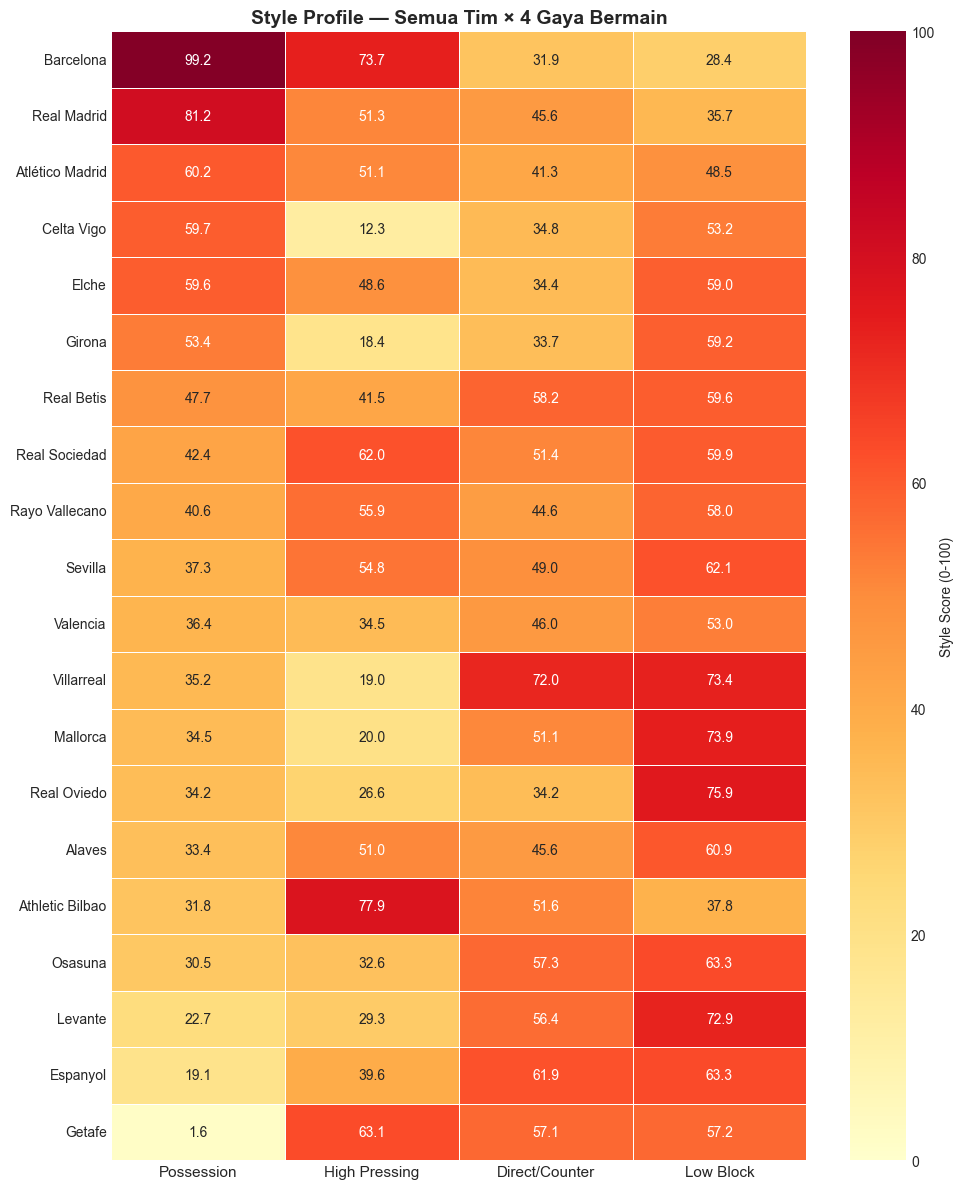

In [6]:
style_cols = list(STYLE_DEFINITIONS.keys())
heatmap_data = styles_df[style_cols].sort_values(style_cols[0], ascending=False)

fig, ax = plt.subplots(figsize=(10, 12))
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, vmin=0, vmax=100,
            cbar_kws={'label': 'Style Score (0-100)'})
ax.set_title('Style Profile — Semua Tim × 4 Gaya Bermain', fontsize=14, fontweight='bold')
ax.set_ylabel('')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=11)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=10)
plt.tight_layout()
plt.show()

## 7. Radar Chart — Per Tim

Pilih tim yang ingin dibandingkan di variabel `SELECTED_TEAMS`.

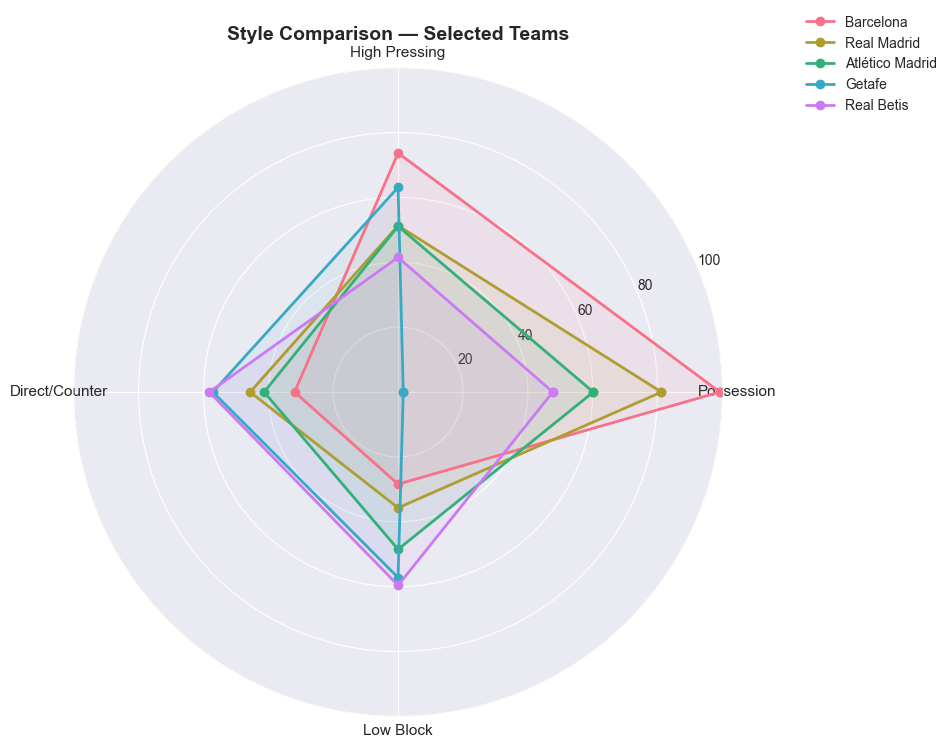

In [7]:
# Pilih tim untuk dibandingkan (ubah sesuai keinginan)
SELECTED_TEAMS = ['Barcelona', 'Real Madrid', 'Atlético Madrid', 'Getafe', 'Real Betis']

style_cols = list(STYLE_DEFINITIONS.keys())
angles = np.linspace(0, 2 * np.pi, len(style_cols), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

colors = sns.color_palette('husl', len(SELECTED_TEAMS))

for i, club in enumerate(SELECTED_TEAMS):
    values = styles_df.loc[club, style_cols].tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, color=colors[i], label=club, markersize=6)
    ax.fill(angles, values, alpha=0.08, color=colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(style_cols, fontsize=11)
ax.set_ylim(0, 100)
ax.set_title('Style Comparison — Selected Teams', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=10)
plt.tight_layout()
plt.show()

## 8. Radar Chart — Setiap Tim (Grid)

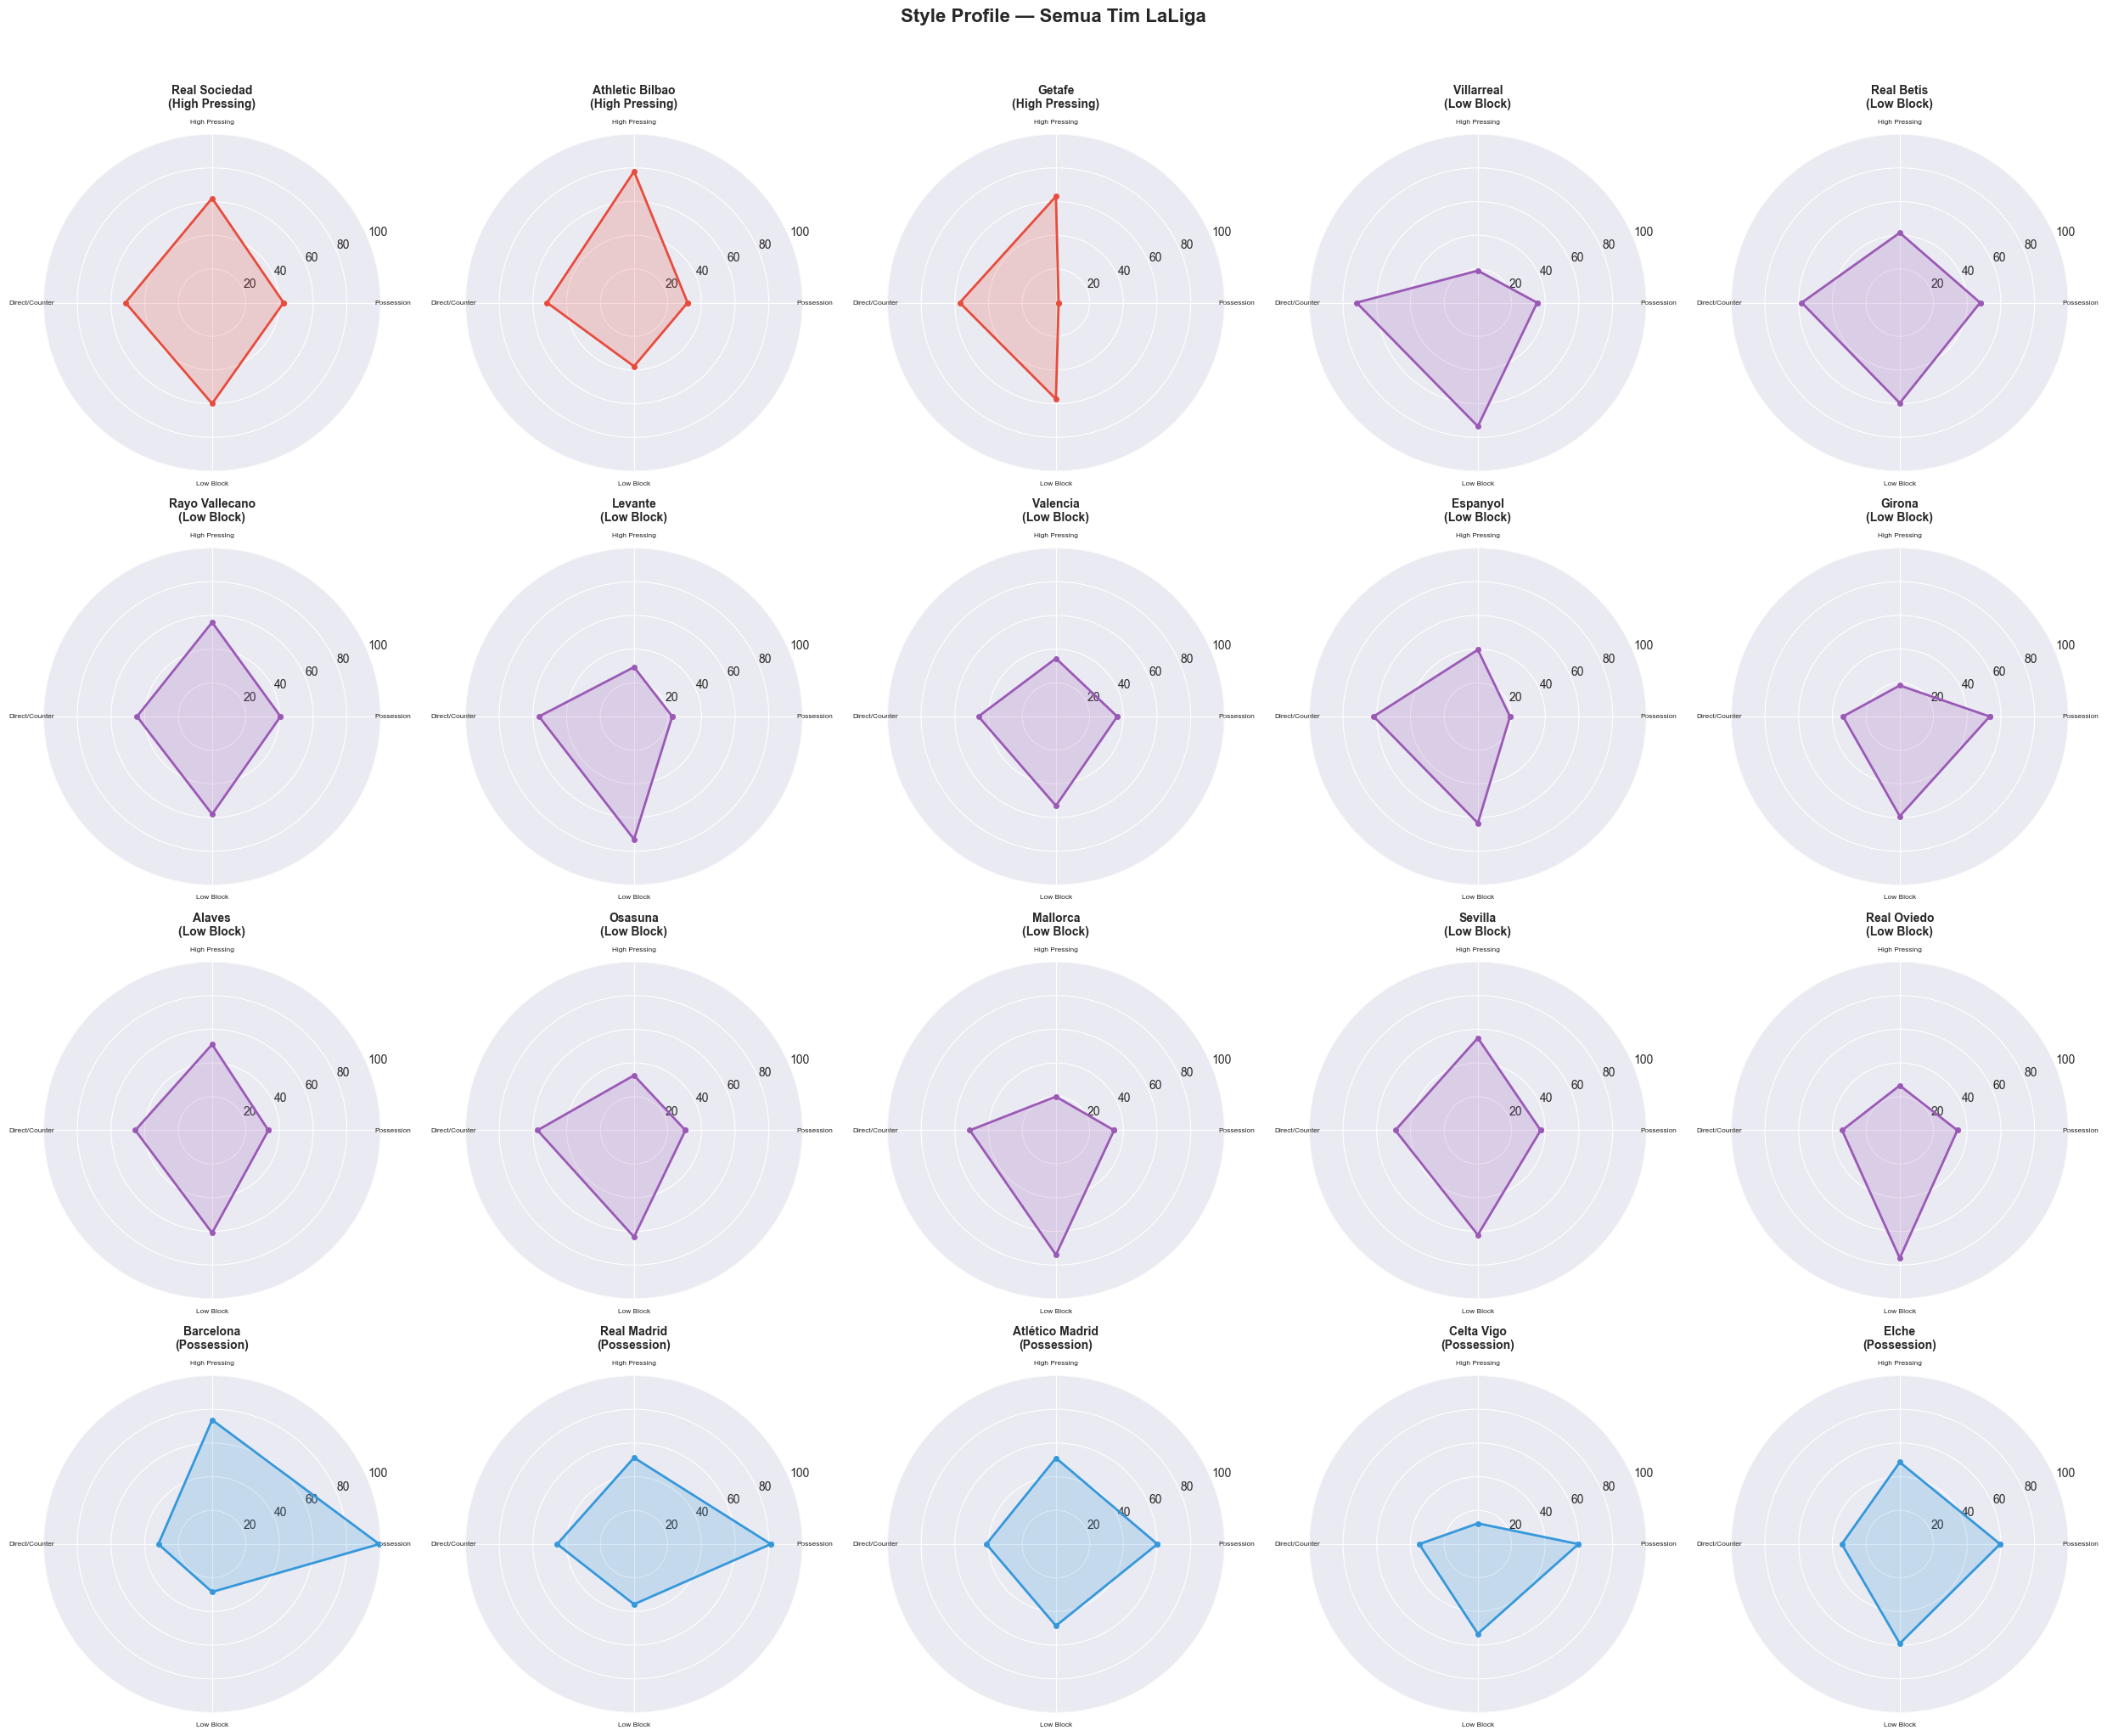

In [8]:
# Radar chart grid — semua 20 tim
ncols = 5
nrows = (len(gold) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 5*nrows),
                         subplot_kw=dict(polar=True))
axes = axes.flatten()

style_cols = list(STYLE_DEFINITIONS.keys())
angles = np.linspace(0, 2 * np.pi, len(style_cols), endpoint=False).tolist()
angles += angles[:1]

# Color by dominant style
style_colors = {
    'Possession': '#3498db',
    'High Pressing': '#e74c3c',
    'Direct/Counter': '#2ecc71',
    'Low Block': '#9b59b6',
}

for i, club in enumerate(styles_df.sort_values('Dominant').index):
    ax = axes[i]
    values = styles_df.loc[club, style_cols].tolist()
    values += values[:1]
    dominant = styles_df.loc[club, 'Dominant']
    color = style_colors.get(dominant, '#95a5a6')

    ax.plot(angles, values, 'o-', linewidth=2, color=color, markersize=4)
    ax.fill(angles, values, alpha=0.2, color=color)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(style_cols, fontsize=6)
    ax.set_ylim(0, 100)
    ax.set_title(f'{club}\n({dominant})', fontsize=10, fontweight='bold', pad=10)

# Hide empty subplots
for j in range(len(gold), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Style Profile — Semua Tim LaLiga', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 9. Stacked Bar — Proporsi Gaya Bermain

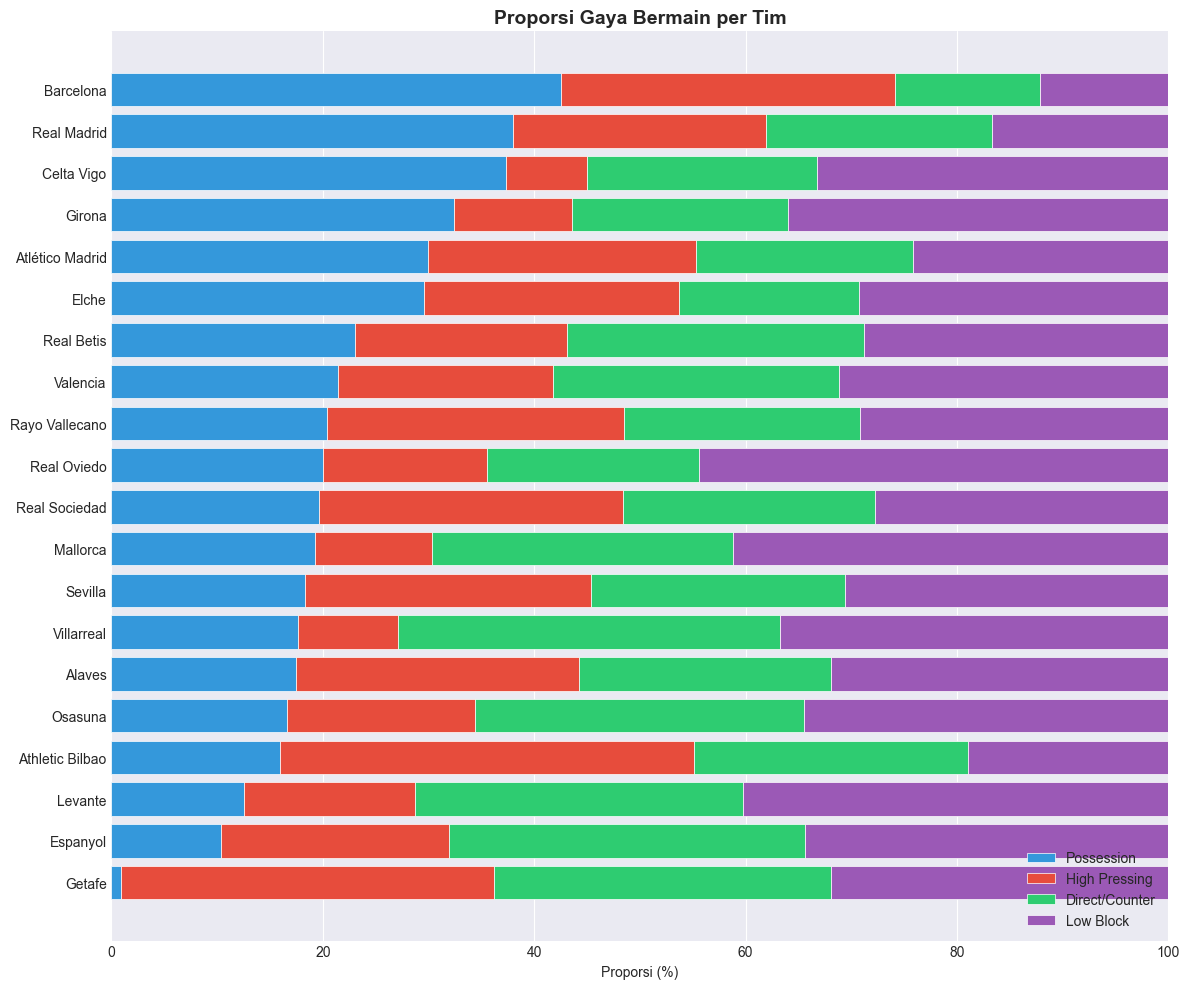

In [9]:
# Stacked bar chart — proportional style
style_cols = list(STYLE_DEFINITIONS.keys())
proportions = styles_df[style_cols].div(styles_df[style_cols].sum(axis=1), axis=0) * 100
proportions = proportions.sort_values('Possession', ascending=True)

fig, ax = plt.subplots(figsize=(12, 10))

style_colors = {
    'Possession': '#3498db',
    'High Pressing': '#e74c3c',
    'Direct/Counter': '#2ecc71',
    'Low Block': '#9b59b6',
}

left = np.zeros(len(proportions))
for style in style_cols:
    ax.barh(proportions.index, proportions[style], left=left,
            color=style_colors[style], label=style, edgecolor='white', linewidth=0.5)
    left += proportions[style].values

ax.set_xlabel('Proporsi (%)')
ax.set_title('Proporsi Gaya Bermain per Tim', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim(0, 100)
plt.tight_layout()
plt.show()

## 10. Lookup — Detail 1 Tim

Ubah variabel `CLUB` untuk melihat detail tim tertentu.

  ⚽ Barcelona

  Possession            ███████████████████░   99.2%  ◄ dominant
  High Pressing         ██████████████░░░░░░   73.7%
  Direct/Counter        ██████░░░░░░░░░░░░░░   31.9%
  Low Block             █████░░░░░░░░░░░░░░░   28.4%

────────────────────────────────────────────────────────────
  Dominant Style: Possession
  Description: Dominasi bola, passing pendek, build-up sabar
────────────────────────────────────────────────────────────


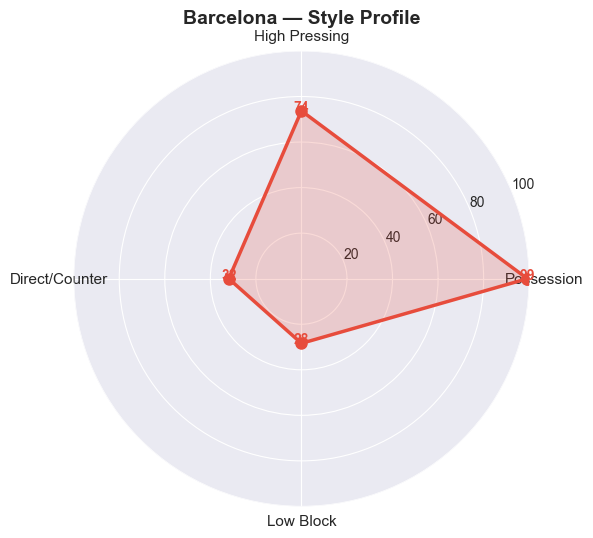

In [10]:
CLUB = 'Barcelona'  # <-- ubah nama tim di sini

if CLUB not in styles_df.index:
    print(f"❌ '{CLUB}' tidak ditemukan. Tim yang tersedia:")
    print(', '.join(sorted(styles_df.index)))
else:
    scores = styles_df.loc[CLUB, list(STYLE_DEFINITIONS.keys())]
    dominant = styles_df.loc[CLUB, 'Dominant']

    print(f"{'='*60}")
    print(f"  ⚽ {CLUB}")
    print(f"{'='*60}")
    print()
    for style in STYLE_DEFINITIONS.keys():
        score = scores[style]
        bar = '█' * int(score / 5) + '░' * (20 - int(score / 5))
        marker = '  ◄ dominant' if style == dominant else ''
        print(f"  {style:20s}  {bar}  {score:5.1f}%{marker}")

    print(f"\n{'─'*60}")
    print(f"  Dominant Style: {dominant}")
    print(f"  Description: {STYLE_DEFINITIONS[dominant]['description']}")
    print(f"{'─'*60}")

    # Mini radar
    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
    style_cols = list(STYLE_DEFINITIONS.keys())
    angles = np.linspace(0, 2 * np.pi, len(style_cols), endpoint=False).tolist()
    angles += angles[:1]
    values = scores.tolist() + [scores.tolist()[0]]

    ax.plot(angles, values, 'o-', linewidth=2.5, color='#e74c3c', markersize=8)
    ax.fill(angles, values, alpha=0.2, color='#e74c3c')
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(style_cols, fontsize=11)
    ax.set_ylim(0, 100)
    ax.set_title(f'{CLUB} — Style Profile', fontsize=14, fontweight='bold', pad=20)

    # Add score labels on the radar
    for angle, val, label in zip(angles[:-1], scores.tolist(), style_cols):
        ax.annotate(f'{val:.0f}', xy=(angle, val), fontsize=10, ha='center',
                    fontweight='bold', color='#e74c3c')

    plt.tight_layout()
    plt.show()

## 11. Simpan Hasil

In [ ]:
output_dir = BASE_DIR / "data" / "gold" / "teams"
output_dir.mkdir(parents=True, exist_ok=True)

styles_df.to_csv(output_dir / "team_style_scores.csv")
print(f"✅ Saved: {output_dir / 'team_style_scores.csv'}")

print(f"\nContoh isi file:")
print(styles_df.head())